In [33]:
import pandas as pd
from IPython.display import display

# Define the data as a list of lists (excluding 'Individual Responsible' column)
data = [
    ["Causal transformer model using position encodings", "Config of the model trained", "Train Time =  6453.80 seconds"],
    ["Training Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.81"], 
    ["", "F1 Score for Negative = ?", "0.50"], 
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Class 0 on Training Data: 0.80, AUC for Class 1 on Training Data: 0.74, AUC for Class 2 on Training Data: 0.81"], 
    ["", "Accuracy computed?", "0.70"], 
    ["Cross Validation", "", ""],
    ["Interpretability", "local(LIME)", "Words highly associated with the negative setiment"],
    ["Testing Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.82"],
    ["", "F1 Score for Negative = ?", "0.90"],
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Class 0 on Test Data: 0.84, AUC for Class 1 on Test Data: 0.76, AUC for Class 2 on Test Data: 0.85"], 
    ["", "Accuracy computed?", "0.75"],     
    ["Data Preprocessing and Feature Engg", "Regex Used?", "yes"],
    ["", "Emoji Handling Done?", "yes"],
    ["", "Slang Handling Done?", "yes"],
    ["", "Abbreviations Handled?", "yes"],
    ["", "Negation Handled?", "yes"],
    ["", "Class Separability Checked?", "yes"],
    ["", "Train and Test Handled Correctly?", "yes"],
]

# Create a DataFrame
Task = pd.DataFrame(data, columns=["Task", "Status", "Results"])

# Display the table in Jupyter Notebook
display(Task)

,Task,Status,Results
0,Causal transformer model using position encodings,Config of the model trained,Train Time = 6453.80 seconds
1,Training Data Check,Confusion Matrix Built?,Yes
2,,F1 Score for Positive = ?,0.81
3,,F1 Score for Negative = ?,0.50
4,,AUC plotted?,Yes
5,,AUC =,"AUC for Class 0 on Training Data: 0.80, AUC fo..."
6,,Accuracy computed?,0.70
7,Cross Validation,,
8,Interpretability,local(LIME),Words highly associated with the negative seti...
9,Testing Data Check,Confusion Matrix Built?,Yes


In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from collections import Counter
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, LayerNormalization, Dropout, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D, MultiHeadAttention, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Accuracy
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [2]:
df = pd.read_csv('Sentiment_Data.csv', nrows=30000, encoding='ISO-8859-1')

# Display the first few rows of the loaded data
df.head()


,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [3]:
class_labels = df['Sentiment'].unique()
print(class_labels)

['Mild_Pos' 'Strong_Pos' 'Neutral' 'Strong_Neg' 'Mild_Neg']


In [4]:
sentiment_map = {
    'Mild_Pos': 'Positive', 'Strong_Pos': 'Positive', 
    'Neutral': 'Neutral', 
    'Strong_Neg': 'Negative', 'Mild_Neg': 'Negative'
}
df['Sentiment'] = df['Sentiment'].map(sentiment_map)
print(df['Sentiment'].unique())  # Should print: ['Positive', 'Neutral', 'Negative']



['Positive' 'Neutral' 'Negative']


# Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df['Tweet'], df['Sentiment'], test_size=0.2, random_state=42)

# Check the distribution of the classes in both sets
print(f"Train set: {y_train.value_counts()}")
print(f"Test set: {y_test.value_counts()}")

Train set: Sentiment
Positive    16429
Negative     4025
Neutral      3546
Name: count, dtype: int64
Test set: Sentiment
Positive    4078
Negative    1060
Neutral      862
Name: count, dtype: int64


# Preprocessing

In [6]:
import emoji

# Function to handle emojis
def handle_emoji(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Apply emoji handling to both train and test sets
X_train = X_train.apply(handle_emoji)
X_test = X_test.apply(handle_emoji)

# Count emojis handled
num_emojis_train = sum(X_train.apply(lambda x: len(re.findall(r'[\U00010000-\U0010ffff]', x))))
num_emojis_test = sum(X_test.apply(lambda x: len(re.findall(r'[\U00010000-\U0010ffff]', x))))
print(f"Number of emojis handled in train set: {num_emojis_train}")
print(f"Number of emojis handled in test set: {num_emojis_test}")


Number of emojis handled in train set: 0
Number of emojis handled in test set: 0


In [7]:
# Example slang dictionary
slang_dict = {
    "u": "you",
    "r": "are",
    "b4": "before",
    "gr8": "great",
    "l8r": "later",
}

# Function to handle slang
def handle_slang(text):
    for slang, replacement in slang_dict.items():
        text = text.replace(slang, replacement)
    return text

# Apply slang handling to both train and test sets
X_train = X_train.apply(handle_slang)
X_test = X_test.apply(handle_slang)

# Count slangs handled
num_slangs_train = sum(X_train.apply(lambda x: len([word for word in slang_dict if word in x])))
num_slangs_test = sum(X_test.apply(lambda x: len([word for word in slang_dict if word in x])))
print(f"Number of slangs handled in train set: {num_slangs_train}")
print(f"Number of slangs handled in test set: {num_slangs_test}")


Number of slangs handled in train set: 45424
Number of slangs handled in test set: 11359


In [8]:
# Example abbreviation dictionary
abbreviation_dict = {
    "bc": "because",
    "lol": "laughing out loud",
    "omg": "oh my god",
}

# Function to handle abbreviations
def handle_abbreviations(text):
    for abbr, full_form in abbreviation_dict.items():
        text = text.replace(abbr, full_form)
    return text

# Apply abbreviation handling to both train and test sets
X_train = X_train.apply(handle_abbreviations)
X_test = X_test.apply(handle_abbreviations)

# Count abbreviations handled
num_abbreviations_train = sum(X_train.apply(lambda x: len([word for word in abbreviation_dict if word in x])))
num_abbreviations_test = sum(X_test.apply(lambda x: len([word for word in abbreviation_dict if word in x])))
print(f"Number of abbreviations handled in train set: {num_abbreviations_train}")
print(f"Number of abbreviations handled in test set: {num_abbreviations_test}")


Number of abbreviations handled in train set: 0
Number of abbreviations handled in test set: 0


In [9]:
# Function to handle negation
def handle_negation(text):
    negation_patterns = ['not', 'no', 'never', 'don\'t', 'won\'t', 'isn\'t', 'aren\'t']
    for negation in negation_patterns:
        text = re.sub(r'\b' + negation + r'\b', negation + '_', text)
    return text

# Apply negation handling to both train and test sets
X_train = X_train.apply(handle_negation)
X_test = X_test.apply(handle_negation)

# Count negation patterns handled
num_negation_patterns_train = sum(X_train.apply(lambda x: len([neg for neg in ['not', 'no', 'never', 'don\'t', 'won\'t', 'isn\'t', 'aren\'t'] if neg in x])))
num_negation_patterns_test = sum(X_test.apply(lambda x: len([neg for neg in ['not', 'no', 'never', 'don\'t', 'won\'t', 'isn\'t', 'aren\'t'] if neg in x])))
print(f"Number of negation patterns handled in train set: {num_negation_patterns_train}")
print(f"Number of negation patterns handled in test set: {num_negation_patterns_test}")


Number of negation patterns handled in train set: 10975
Number of negation patterns handled in test set: 2824


In [10]:
# Feature extraction (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Print the shape of the transformed TF-IDF features
print(f"TF-IDF feature set for train: {X_train_tfidf.shape}")
print(f"TF-IDF feature set for test: {X_test_tfidf.shape}")


TF-IDF feature set for train: (24000, 5000)
TF-IDF feature set for test: (6000, 5000)


# Label encoding

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Fit and transform on training data
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform on test data
y_test = label_encoder.transform(y_test)
y_train= np.array(y_train_encoded, dtype='int32')
# Verify the unique classes after encoding
print("Encoded y_train classes:", np.unique(y_train))
print("Encoded y_test classes:", np.unique(y_test))


Encoded y_train classes: [0 1 2]
Encoded y_test classes: [0 1 2]


# Checking class separability

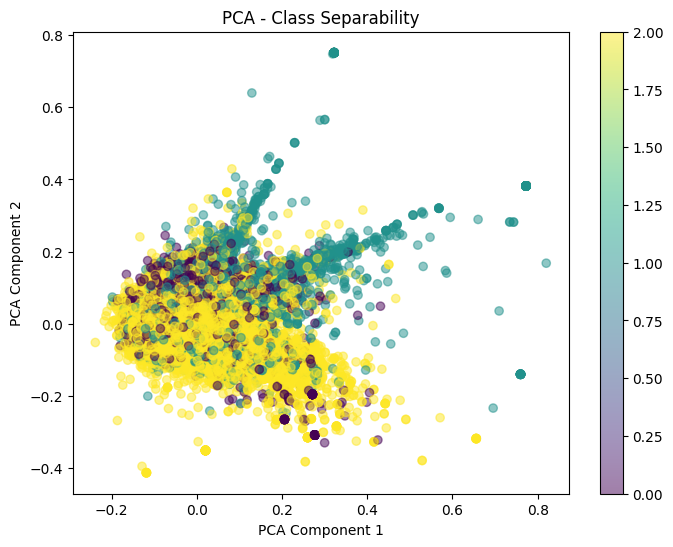

TypeError: PCA initialization is currently not supported with the sparse input matrix. Use init="random" instead.

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Function to visualize class separability using PCA
def visualize_pca(X_train_tfidf, y_train):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train_tfidf)  # No need to call .toarray() here
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5)
    plt.colorbar()
    plt.title("PCA - Class Separability")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Function to visualize class separability using t-SNE
def visualize_tsne(X_train_tfidf, y_train):
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_train_tfidf)  # No need to call .toarray() here
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.5)
    plt.colorbar()
    plt.title("t-SNE - Class Separability")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Visualize the separability using PCA
visualize_pca(X_train_tfidf, y_train)

# Visualize the separability using t-SNE
visualize_tsne(X_train_tfidf, y_train)
X_train_dense = X_train_tfidf.toarray()  # Convert sparse matrix to dense
X_tsne = tsne.fit_transform(X_train_dense)



# Tokenization

In [13]:
# Initialize the tokenizer
tokenizer = Tokenizer()

# Fit the tokenizer only on the training data

tokenizer.fit_on_texts(X_train)

# Convert both the train and test text to sequences using the same tokenizer
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad the sequences to ensure uniform length
X_train_seq = pad_sequences(X_train_seq, padding='post')
X_test_seq = pad_sequences(X_test_seq, padding='post')

# Check the shape of the tokenized input
print(f"Shape of tokenized train set: {X_train_seq.shape}")
print(f"Shape of tokenized test set: {X_test_seq.shape}")

Shape of tokenized train set: (24000, 228)
Shape of tokenized test set: (6000, 156)


# Balancing

Class distribution before balancing:
2    16429
0     4025
1     3546
Name: count, dtype: int64


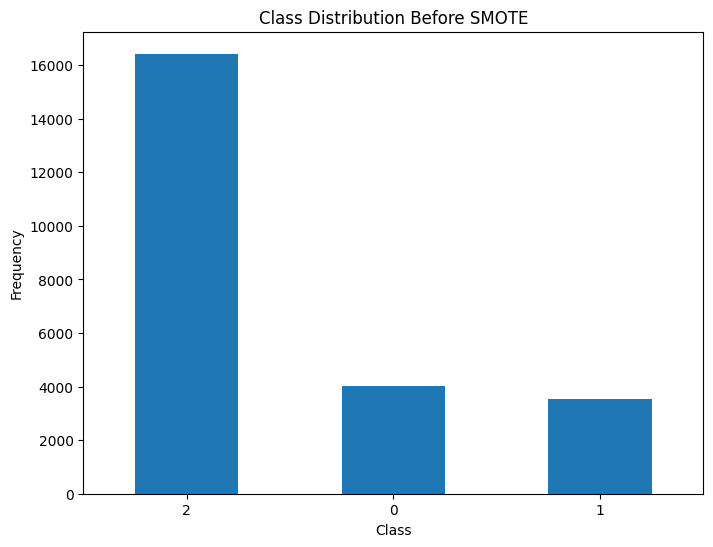

C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Class distribution after SMOTE:
2    16429
0    16429
1    16429
Name: count, dtype: int64


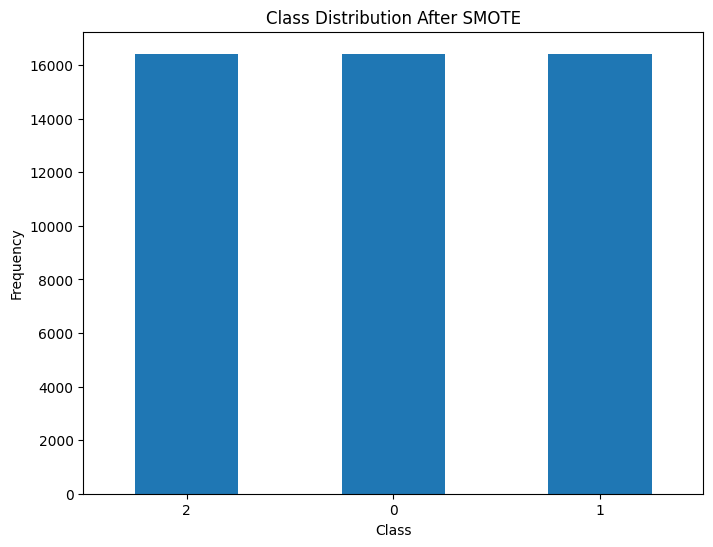

Shape of X_train_seq: (49287, 228)
Shape of y_train: (49287,)


In [14]:
# Check initial class distribution in the training set
print("Class distribution before balancing:")
print(pd.Series(y_train).value_counts())

# Plot initial class distribution
plt.figure(figsize=(8, 6))
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

# Apply SMOTE for balancing the classes
smote = SMOTE(random_state=42)

# Apply SMOTE on the training data
X_train, y_train = smote.fit_resample(X_train_seq, y_train)

# Check the class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train).value_counts())

# Plot the new class distribution after SMOTE
plt.figure(figsize=(8, 6))
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()
print("Shape of X_train_seq:", X_train.shape)  # (28000, 60)
print("Shape of y_train:", y_train.shape)   

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_seq = pad_sequences(X_train, maxlen=100, padding='post', truncating='post')
X_test_seq = pad_sequences(X_test_seq, maxlen=100, padding='post', truncating='post')

print(X_train_seq.shape)  # Should be (num_samples, 60)
print("Shape of X_train_seq:", X_train_seq.shape)  # (28000, 60)
print("Shape of y_train:", y_train.shape)          # (56394,)
print("Shape of y_train:", y_train.shape)  # Should be (56394,)
print("Unique y_train classes:", np.unique(y_train))  # Ensure class labels are integers
print("Unique y_test classes:", np.unique(y_test))


(49287, 100)
Shape of X_train_seq: (49287, 100)
Shape of y_train: (49287,)
Shape of y_train: (49287,)
Unique y_train classes: [0 1 2]
Unique y_test classes: [0 1 2]


# Model Implementation

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Add, LayerNormalization, MultiHeadAttention, Lambda, Dropout
from tensorflow.keras.models import Model
import numpy as np

# Positional Encoding
def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    dimensions = np.arange(d_model)[np.newaxis, :]

    # Compute the angle rates for positional encoding
    angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / np.float32(d_model))
    pos_enc = positions * angle_rates

    # Apply sin to even indices, cos to odd indices
    pos_enc[:, 0::2] = np.sin(pos_enc[:, 0::2])  # Apply sin to even indices
    pos_enc[:, 1::2] = np.cos(pos_enc[:, 1::2])  # Apply cos to odd indices

    # Convert to TensorFlow Tensor and return (1, seq_len, d_model)
    pos_enc = tf.cast(pos_enc, dtype=tf.float32)

    return tf.expand_dims(pos_enc, axis=0)  # For broadcasting

# Causal Masking Function
def create_causal_mask(seq_len):
    """Generates a causal mask to ensure attention is only to previous tokens."""
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask

# Transformer Model with Causal Masking
def causal_transformer_model(vocab_size, seq_len, num_classes, embedding_dim=128):
    inputs = Input(shape=(seq_len,))
    
    # Embedding Layer with a larger input_dim
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    
    # Positional Encoding
    pos_enc = positional_encoding(seq_len, embedding_dim)

    # Add positional encoding to the embedding
    embedding_with_pos = Add()([embedding_layer, pos_enc])

    # Causal Masking
    causal_mask = create_causal_mask(seq_len)

    # Multi-Head Attention with causal masking (future tokens masked)
    mha = MultiHeadAttention(num_heads=4, key_dim=embedding_dim)(embedding_with_pos, embedding_with_pos, attention_mask=causal_mask)

    # Add residual connection + Layer Normalization
    x = Add()([embedding_with_pos, mha])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Dropout for regularization
    x = Dropout(0.1)(x)

    # Apply Global Average Pooling using Lambda
    x = Lambda(lambda y: tf.reduce_mean(y, axis=1))(x)

    # Output Layer for classification
    outputs = Dense(num_classes, activation='softmax')(x)

    # Define and compile model
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile model with Adam optimizer and sparse categorical cross-entropy loss
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

# Example Usage
vocab_size = 54352        # Set a larger vocabulary size, e.g., 50000
max_sequence_length = 100  # Maximum sequence length
num_classes = len(np.unique(y_train)) 
embedding_dim = 128        # Embedding dimension

model = causal_transformer_model(vocab_size, max_sequence_length, num_classes, embedding_dim)

# Model Summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 100, 128)          │       6,957,056 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (1, 100, 128)             │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (1, 100, 128)             │         263,808 │ add[0][0], add[0][0]       │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (1, 100, 128)             │               0 │ add[0][0],                 │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (1, 100, 128)             │             256 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (1, 100, 128)             │               0 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (1, 128)                  │               0 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (1, 3)                    │             387 │ lambda[0][0]               │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 7,221,507 (27.55 MB)

 Trainable params: 7,221,507 (27.55 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [18]:
from tensorflow.keras.callbacks import Callback
import time
X_train_seq = np.array(X_train_seq, dtype='int32')

class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_duration = time.time() - self.epoch_start_time
        self.times.append(epoch_duration)  # Store epoch duration
        print(f"Epoch {epoch + 1} time: {epoch_duration:.2f} seconds")

# Correct: Class is fully defined before using it.

# Create an instance of the callback
time_callback = TimeHistory()

# Pass callback during model training
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, callbacks=[time_callback])

# Print the recorded times
print("Training time per epoch: ", time_callback.times)


Epoch 1/10
Epoch 1 time: 684.35 seconds━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.5148 - loss: 0.9857   
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 684s 436ms/step - accuracy: 0.5148 - loss: 0.9857
Epoch 2/10
Epoch 2 time: 680.07 seconds━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6973 - loss: 0.6782   
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 680s 441ms/step - accuracy: 0.6973 - loss: 0.6782
Epoch 3/10
Epoch 3 time: 653.16 seconds━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.7640 - loss: 0.5319   
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 653s 424ms/step - accuracy: 0.7640 - loss: 0.5319
Epoch 4/10
Epoch 4 time: 636.10 seconds━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8198 - loss: 0.4157   
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 636s 413ms/step - accuracy: 0.8198 - loss: 0.4157
Epoch 5/10
Epoch 5 time: 633.60 seconds━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8725 - loss: 0.3080   
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 634s 411ms/step - accuracy: 0.8725 - loss: 0.3080
Epoch 6/10
Epoch 6 time: 682.54 seconds━━━━━━━━━━━━━━━ 0s 411ms/s

# Model evaluation

188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step
y_test shape:  (6000,)
y_pred_labels shape:  (6000,)
Confusion Matrix:
 [[ 631  149  280]
 [ 209  329  324]
 [ 604  221 3253]]


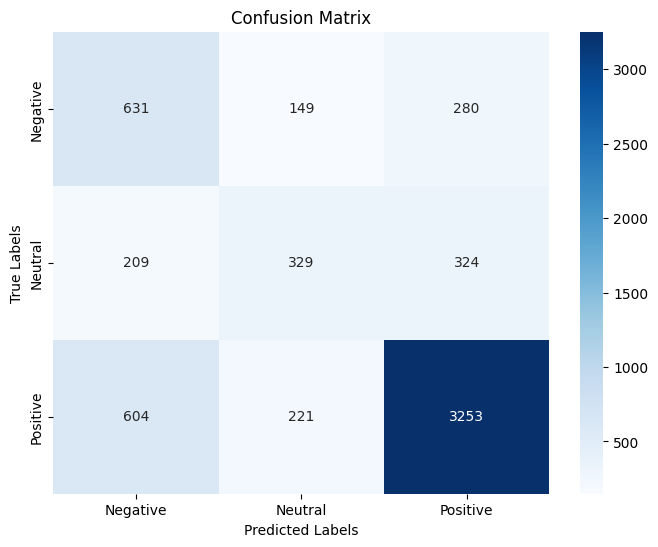

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_classes = model.predict(X_test_seq) 
# Convert multi-label predictions to single-label
y_pred_labels = np.argmax(y_pred_classes, axis=1)

# Ensure both y_test and y_pred_labels are 1D and match
print("y_test shape: ", y_test.shape)          # (4000,)
print("y_pred_labels shape: ", y_pred_labels.shape)  # (4000,)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

# Define class labels (Ensure these match your model's output)
class_labels = ['Negative', 'Neutral', 'Positive']

# ✅ Standardized Confusion Matrix (with heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


✅ F1 Score (Negative): 0.5040
✅ F1 Score (Neutral): 0.4215
✅ F1 Score (Positive): 0.8199
✅ AUC for Negative: 0.8003
✅ AUC for Neutral: 0.7467
✅ AUC for Positive: 0.8128


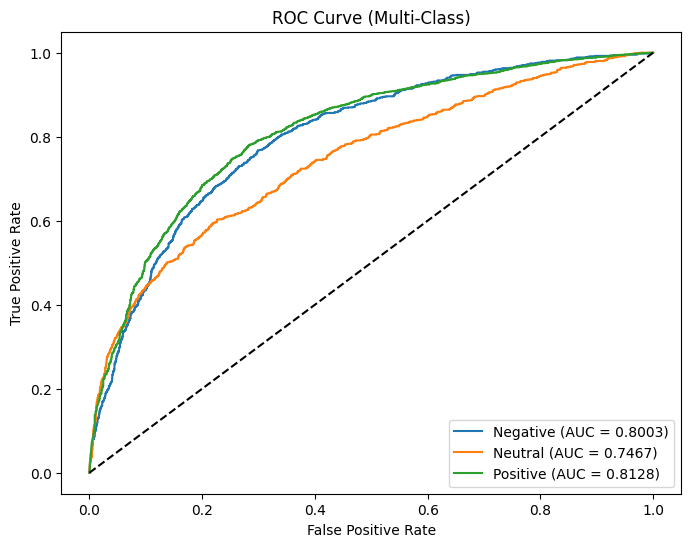

✅ Accuracy: 0.7022

Classification Report:
               precision    recall  f1-score   support

    Negative       0.44      0.60      0.50      1060
     Neutral       0.47      0.38      0.42       862
    Positive       0.84      0.80      0.82      4078

    accuracy                           0.70      6000
   macro avg       0.58      0.59      0.58      6000
weighted avg       0.72      0.70      0.71      6000



In [21]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, accuracy_score, classification_report
import matplotlib.pyplot as plt

# ✅ 1. F1 Score Calculation (For Each Class)
f1_scores = f1_score(y_test, y_pred_labels, average=None)  # F1 for each class

print(f"✅ F1 Score (Negative): {f1_scores[0]:.4f}")
print(f"✅ F1 Score (Neutral): {f1_scores[1]:.4f}")
print(f"✅ F1 Score (Positive): {f1_scores[2]:.4f}")

# ✅ 2. AUC Calculation & ROC Curve (for multi-class)
y_test_bin = np.eye(len(class_labels))[y_test]  # One-hot encode true labels

# Compute AUC for each class
auc_scores = roc_auc_score(y_test_bin, y_pred_classes, average=None)
for i, label in enumerate(class_labels):
    print(f"✅ AUC for {label}: {auc_scores[i]:.4f}")

# ROC Curve for each class
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_classes[:, i])
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {auc_scores[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-Class)')
plt.legend(loc="lower right")
plt.show()

# ✅ 3. Accuracy Calculation
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"✅ Accuracy: {accuracy:.4f}")

# ✅ Optional: Detailed Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_labels, target_names=class_labels))


# Model Tuning

In [22]:
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Compute Class Weights for Imbalance
import numpy as np
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Modify Your Model for Tuning
def create_model(dropout_rate=0.3, attention_heads=4, lr=0.0005):
    input_layer = Input(shape=(100,), name="input_layer")
    embedding_layer = Embedding(input_dim=55000, output_dim=128, input_length=100)(input_layer)

    # Multi-head Attention with Regularization
    attention = MultiHeadAttention(num_heads=attention_heads, key_dim=128)(embedding_layer, embedding_layer)
    add_attention = Add()([embedding_layer, attention])
    norm_attention = LayerNormalization()(add_attention)
    dropout = Dropout(dropout_rate)(norm_attention)

    # Global Context Vector
    pooled_output = Lambda(lambda x: tf.reduce_mean(x, axis=1))(dropout)

    # Final Dense Layer with L2 Regularization
    output_layer = Dense(3, activation='softmax', kernel_regularizer=l2(0.01))(pooled_output)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Hyperparameter Search
dropout_rates = [0.2, 0.3, 0.5]
attention_heads = [2, 4, 8]
learning_rates = [0.0005, 0.001]

best_model = None
best_score = 0

for dr in dropout_rates:
    for ah in attention_heads:
        for lr in learning_rates:
            model = create_model(dropout_rate=dr, attention_heads=ah, lr=lr)
            print(f"Tuning Model: Dropout={dr}, Heads={ah}, LR={lr}")

            history = model.fit(X_train_seq, y_train,
                                validation_split=0.2,
                                epochs=10,
                                batch_size=64,
                                class_weight=class_weight_dict,
                                callbacks=[EarlyStopping(monitor='val_loss', patience=2)])

            val_acc = max(history.history['val_accuracy'])
            if val_acc > best_score:
                best_score = val_acc
                best_model = model

print(f"Best Accuracy: {best_score}")


C:\Users\anjit\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Tuning Model: Dropout=0.2, Heads=2, LR=0.0005
Epoch 1/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 233s 354ms/step - accuracy: 0.5667 - loss: 0.9980 - val_accuracy: 0.2107 - val_loss: 1.7074
Epoch 2/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 211s 342ms/step - accuracy: 0.7471 - loss: 0.6747 - val_accuracy: 0.2524 - val_loss: 1.5854
Epoch 3/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 241s 390ms/step - accuracy: 0.8182 - loss: 0.5032 - val_accuracy: 0.2602 - val_loss: 1.9152
Epoch 4/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 223s 362ms/step - accuracy: 0.8941 - loss: 0.3213 - val_accuracy: 0.2589 - val_loss: 2.4255
Tuning Model: Dropout=0.2, Heads=2, LR=0.001
Epoch 1/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 229s 342ms/step - accuracy: 0.5876 - loss: 1.0036 - val_accuracy: 0.1768 - val_loss: 1.5979
Epoch 2/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 261s 341ms/step - accuracy: 0.7519 - loss: 0.6495 - val_accuracy: 0.2246 - val_loss: 1.6410
Epoch 3/10
617/617 ━━━━━━━━━━━━━━━━━━━━ 258s 334ms/step - accuracy: 0.8406 - loss: 0.4494 - val_accuracy: 0.2027 - va

# Cross Validation

In [23]:
from sklearn.model_selection import KFold
import numpy as np

# Define number of folds
k = 5  # 5-Fold Cross-Validation
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Store results
fold_no = 1
cv_scores = []

for train_idx, val_idx in kf.split(X_train_seq):
    print(f"\nTraining on Fold {fold_no}...")

    # Split data into training and validation
    X_train_fold, X_val_fold = X_train_seq[train_idx], X_train_seq[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Reinitialize the model for each fold
    model = causal_transformer_model(vocab_size, max_sequence_length, num_classes, embedding_dim)

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=1)

    # Evaluate the model on validation data
    score = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold_no} - Loss: {score[0]:.4f}, Accuracy: {score[1]:.4f}")

    # Store the accuracy score
    cv_scores.append(score[1])
    fold_no += 1

# Print overall cross-validation accuracy
print(f"\nAverage Accuracy across {k} folds: {np.mean(cv_scores):.4f}")




Training on Fold 1...
Epoch 1/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 421s 332ms/step - accuracy: 0.4732 - loss: 1.0163
Epoch 2/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 402s 326ms/step - accuracy: 0.6868 - loss: 0.7087
Epoch 3/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 393s 318ms/step - accuracy: 0.7627 - loss: 0.5547
Epoch 4/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 461s 374ms/step - accuracy: 0.8236 - loss: 0.4296
Epoch 5/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 389s 316ms/step - accuracy: 0.8693 - loss: 0.3254
Fold 1 - Loss: 0.9303, Accuracy: 0.6358

Training on Fold 2...
Epoch 1/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 421s 334ms/step - accuracy: 0.4890 - loss: 1.0023
Epoch 2/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 390s 316ms/step - accuracy: 0.6879 - loss: 0.7049
Epoch 3/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 413s 335ms/step - accuracy: 0.7658 - loss: 0.5354
Epoch 4/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 411s 333ms/step - accuracy: 0.8322 - loss: 0.4027
Epoch 5/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 389s 315ms/step - accuracy: 0.8942 - loss: 0.2681
Fold

# Evaluation on Test data


188/188 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step


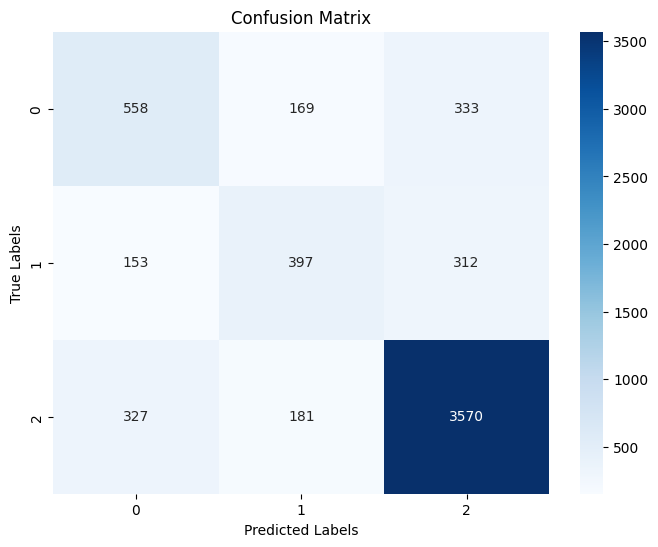

F1 Score (Class 0): 0.5319
F1 Score (Class 1): 0.4935
F1 Score (Class 2): 0.8610
Accuracy: 0.7542
AUC Score (Overall Multi-Class OVR): 0.8226
AUC Score (Class 0): 0.8434
AUC Score (Class 1): 0.7681
AUC Score (Class 2): 0.8564


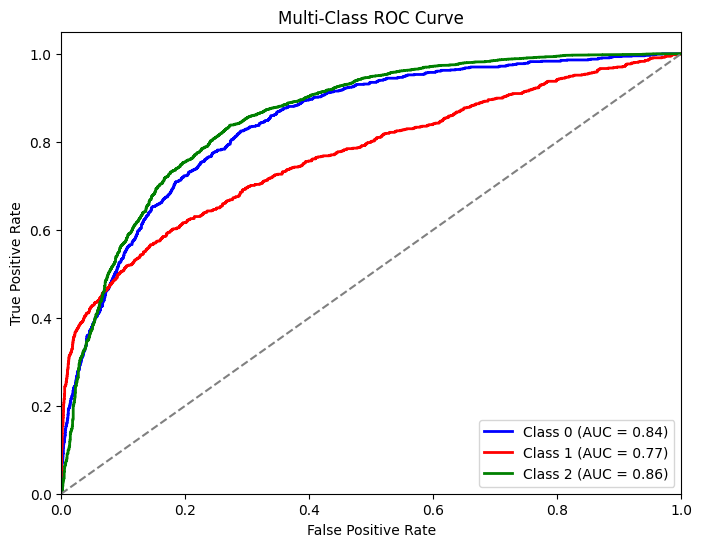

In [29]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    accuracy_score, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from itertools import cycle  # For different colors in multi-class ROC

# Ensure y_test is label-encoded if needed (in case it's string-encoded)
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)

# Predict on test data
y_pred_probs = best_model.predict(X_test_seq)  # Get probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class predictions

# Ensure y_test and y_pred have the same length
y_pred = y_pred[:len(y_test_encoded)]

# Compute Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
report = classification_report(y_test_encoded, y_pred, output_dict=True)

# Extract F1 scores for each class
f1_scores = {label: report[str(label)]['f1-score'] for label in report if label.isdigit()}

for label, f1_score in f1_scores.items():
    print(f"F1 Score (Class {label}): {f1_score:.4f}")

# Compute Accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Compute AUC Scores for each class
num_classes = len(np.unique(y_test_encoded))
auc_scores = {}
auc_score = roc_auc_score(y_test_encoded, y_pred_probs, multi_class='ovr')
print(f"AUC Score (Overall Multi-Class OVR): {auc_score:.4f}")

# Fix indentation issue here
for i in range(num_classes):
    auc_scores[label_encoder.classes_[i]] = roc_auc_score(
        (y_test_encoded == i).astype(int), y_pred_probs[:, i]
    )
    print(f"AUC Score (Class {label_encoder.classes_[i]}): {auc_scores[label_encoder.classes_[i]]:.4f}")

# Plot ROC Curve for Each Class
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray'])

# Fix indentation issue here
for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve((y_test_encoded == i).astype(int), y_pred_probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {label_encoder.classes_[i]} (AUC = {auc_scores[label_encoder.classes_[i]]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.show()


# LIME

In [26]:
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
import numpy as np

# Define the LIME prediction function
def predict_proba_wrapper(texts):
    # Convert text input into sequences (e.g., using tokenizer)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_sequence_length)

    # Make predictions
    return model.predict(padded_sequences)

# Initialize LIME explainer (assuming binary or multi-class classification)
explainer = LimeTextExplainer(class_names=['Class 0', 'Class 1'])  # Adjust class names based on your problem

# Function to explain a single instance
def explain_instance(instance_idx):
    # Get the text data from X_test (the raw text)
    text_instance = X_test.iloc[instance_idx]  # Make sure X_test contains the raw text data
    
    # Generate the explanation for the given instance
    exp = explainer.explain_instance(text_instance, 
                                      predict_proba_wrapper,  
                                      num_features=10)  # Number of features to display in explanation
    
    # Show the explanation in the notebook
    exp.show_in_notebook(text=True)

# Example: Explain the prediction for the first instance in the test set
explain_instance(0)  # Change index to explain other instances



157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step


# Next Steps

In [35]:
# Next steps to print
next_steps = [
    "* Refining Model Outputs: Adjust classification threshold and review results for consistency.",
    "* Improving Text Preprocessing: Enhance tokenization, handle spelling errors, and preprocess emojis/slang."
]

# Print the next steps
for step in next_steps:
    print(step)


* Refining Model Outputs: Adjust classification threshold and review results for consistency.
* Improving Text Preprocessing: Enhance tokenization, handle spelling errors, and preprocess emojis/slang.
